In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 
from datetime import date, timedelta
from darts.utils.missing_values import fill_missing_values


# TODO
### Test low frequency and high frequency VOL_INTERVAL

# PB
#### Transition to Darts TimeSeries makes a lot lot NaN values (5000 for a 17000 df on hour interval)

### Variables

In [83]:
CURRENCIE_TICKER = "EURUSD=X" #, "CAD=X"
#START_DATE, END_DATE = "2014-01-01", "2024-01-01"
#for 1d "2014-01-01", "2024-01-01"
#for 5m (date.today() - timedelta(days=59)).isoformat(), date.today().isoformat() 
# for 1h (date.today() - timedelta(days=720)).isoformat(), date.today().isoformat() 
# for less than 1h interval, only 60 LAST days data are saved. For 1m, only 8 LAST days

TRAIN_SIZE = 0.75
VAL_SIZE = 0.15

VOL_INTERVAL = "5m" #In "1m”, “2m”, “5m”, “15m”, “30m”, “60m”, “90m”, “1h”, “1d”, “5d”, “1wk”, “1mo”, “3mo”
#REALISED_VOL_INTERVAL = "1h"
#DARTS_FREQ = VOL_INTERVAL # 5T pour 5 minutes, peut utiliser VOL_INTERVAL pour 1d

#ROLLING_WINDOW = 5  #for the variance, 24 if hourly for exemple, 20 for 5m, 5 for daily

NBEATS_LOG = 20
NBEATS_FORECAST = 1

if VOL_INTERVAL == "1d" :
    DARTS_FREQ = VOL_INTERVAL
    ROLLING_WINDOW = 5
    START_DATE, END_DATE = "2014-01-01", "2024-01-01"
else: #else it s 5min
    DARTS_FREQ = "5T"
    ROLLING_WINDOW = 20
    START_DATE, END_DATE = (date.today() - timedelta(days=59)).isoformat(), date.today().isoformat() 



# Data

In [84]:

data = yf.download(CURRENCIE_TICKER, start=START_DATE, end=END_DATE, interval=VOL_INTERVAL, progress=False)
data_prices = data["Close"].copy()
data_prices.dropna(inplace=True)

data_prices.set_index(data_prices.index, inplace=True)
data_prices.columns = [CURRENCIE_TICKER]

data_log_returns = np.log(data_prices / data_prices.shift(1)).dropna()*100 + 1.e-08 
data_log_returns_sq = data_log_returns**2

# check data
print(data_log_returns.info())
data_log_returns_sq.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11907 entries, 2026-02-09 00:05:00+00:00 to 2026-04-07 22:55:00+00:00
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  11907 non-null  float64
dtypes: float64(1)
memory usage: 186.0 KB
None


,EURUSD=X
Datetime,
2026-02-09 00:05:00+00:00,1.398687e-04
2026-02-09 00:10:00+00:00,5.603633e-04
2026-02-09 00:15:00+00:00,1.260249e-03
2026-02-09 00:20:00+00:00,1.000000e-16
2026-02-09 00:25:00+00:00,1.399023e-04


# PLOT


In [85]:
df = data_log_returns.copy()[CURRENCIE_TICKER].rolling(ROLLING_WINDOW).var() * 100
df.drop(df.index[:ROLLING_WINDOW], inplace=True)
df = df.to_frame()
df.index = df.index.tz_localize(None) # .tz_convert('UTC')
len(df)

11887

In [94]:
# Découpe ton DataFrame en segments continus
def split_into_continuous_segments(df, freq=VOL_INTERVAL, gap_threshold=1, MIN_LENGTH = NBEATS_LOG+NBEATS_FORECAST):
    """Retourne une liste de DataFrames sans trous."""
    df = df.sort_index()
    if df.index.tz is not None:
        df.index = df.index.tz_convert('UTC').tz_localize(None)
    expected = pd.date_range(df.index[0], df.index[-1], freq=freq)

    ######
    
    ######
    if VOL_INTERVAL == "5m":
        gaps = df.index.to_series().diff() > pd.Timedelta(freq) * gap_threshold
        
        segments = []
        start = 0
        for i, is_gap in enumerate(gaps):
            if is_gap:
                segments.append(df.iloc[start:i])
                start = i
        segments.append(df.iloc[start:])
    else :
        df = df.reindex(expected)
        df = df.interpolate(method='time', limit=3)
        gap_mask = df.iloc[:, 0].isna()
        segments = []
        current = []

        for idx, is_gap in zip(df.index, gap_mask):
            if not is_gap:
                current.append(idx)
            elif current:
                segments.append(df.loc[current])
                current = []
        if current:
            segments.append(df.loc[current])
    
    return [s for s in segments if len(s) > MIN_LENGTH]

segments = split_into_continuous_segments(df)

# Convertir chaque segment en TimeSeries DARTS
series_list = [
    TimeSeries.from_dataframe(seg, freq=DARTS_FREQ)
    for seg in segments
]


In [96]:
# pre traitement pour faire apparaitre tous les indices pour éviter les NaN dans TimeSeries
if VOL_INTERVAL == "1d":
    df_ts =  TimeSeries.from_dataframe(df.asfreq(DARTS_FREQ), freq=DARTS_FREQ)
    df = pd.DataFrame(df_ts.values(), index=df_ts.time_index).interpolate(method="time")
    df_ts = TimeSeries.from_dataframe(df.asfreq(VOL_INTERVAL))
    len(df)

In [97]:
df[df.isna().any(axis=1)] 

,EURUSD=X
Datetime,


In [98]:
# quand c'est segmenté


if len(series_list) > 1:
    train_end = int(TRAIN_SIZE * len(series_list))
    val_end   = int((TRAIN_SIZE + VAL_SIZE) * len(series_list))
    df_train = series_list[:train_end]
    df_val   = series_list[train_end:val_end]
    df_test  = series_list[val_end:]
else:
    train_end = int(TRAIN_SIZE * len(series_list[0]))
    val_end   = int((TRAIN_SIZE + VAL_SIZE) * len(series_list[0]))
    df_train = [series_list[0][:train_end]]
    df_val   = [series_list[0][train_end:val_end]]
    df_test  = [series_list[0][val_end:]]

In [ ]:
# train_end = int(TRAIN_SIZE * len(df))
# val_end   = int((TRAIN_SIZE + VAL_SIZE) * len(df))


# df_train = df.iloc[:train_end]
# df_val   = df.iloc[train_end:val_end]
# df_test  = df.iloc[val_end:]

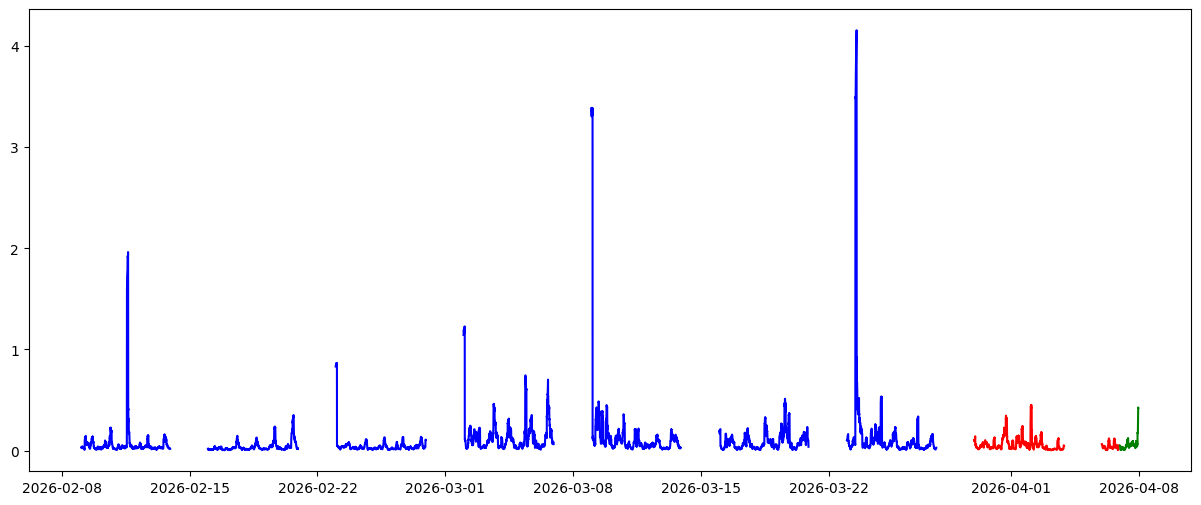

In [99]:
plt.figure(figsize=(15,6))
for d in df_train:
    plt.plot(d.time_index, d.values(), c='b', label="Train")
for d in df_val:
    plt.plot(d.time_index, d.values(), c='r', label="Validation")
for d in df_test:
    plt.plot(d.time_index, d.values(), c='g', label="Test")

In [ ]:
# plt.figure(figsize=(15,6))
# plt.plot(df.index, df.values)

In [ ]:
# print(df_train.index.min(), df_train.index.max())
# print(df_val.index.min(), df_val.index.max())
# print(df_test.index.min(), df_test.index.max())

In [ ]:
# plt.figure(figsize=(12, 5))

# plt.plot(df_train.index, df_train, label="train")
# plt.plot(df_val.index, df_val, label="val")
# plt.plot(df_test.index, df_test, label="test")

# plt.title("Data Split")
# plt.legend()
# plt.show()

In [ ]:
# df_train[pd.DataFrame(df_train).isna().any(axis=1)] 

# Scaler

In [100]:
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled_series_list = [scaler.fit_transform(series_list[0])]

for i in range(1,len(df_train)):
    train_scaled_series_list.append(scaler.transform(df_train[i]))

val_scaled_series_list = [
    scaler.transform(s)
    for s in df_val
]

test_scaled_series_list = [
    scaler.transform(s)
    for s in df_test
]

In [ ]:
# # Résolu : (des NaN apparaissent car il manque surement des heures dans la continuité)
# df_ts =  TimeSeries.from_dataframe(df.asfreq(VOL_INTERVAL))
# train_ts = TimeSeries.from_dataframe(df_train.asfreq(VOL_INTERVAL))
# val_ts = TimeSeries.from_dataframe(df_val.asfreq(VOL_INTERVAL))
# test_ts =  TimeSeries.from_dataframe(df_test.asfreq(VOL_INTERVAL))

In [ ]:
# df_ts.to_dataframe().isna().sum()

In [ ]:
# scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

# train_scaled = scaler.fit_transform(train_ts)
# val_scaled = scaler.transform(val_ts)
# test_scaled = scaler.transform(test_ts)
# df_scaled = scaler.transform(df_ts)

# NBEATS

In [101]:
seed = 42
nbeats_name = f"nbeats_{VOL_INTERVAL}"

# parameters
params = {
    'input_lags': NBEATS_LOG,
    'output_steps': NBEATS_FORECAST,
    'stacks': 5,
    'blocks': 1,
    'layers': 4,
    'l_widths': 256,
    'epochs': 2,
    'b_size': 32
}

In [102]:

start = time.time()
model_nbeats = NBEATSModel(
    input_chunk_length=params['input_lags'],       # use last 20 observations
    output_chunk_length=params['output_steps'],       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=params['stacks'],
    num_blocks=params['blocks'],
    num_layers=params['layers'],
    layer_widths=params['l_widths'],
    n_epochs=params['epochs'], 
    batch_size=params['b_size'],
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled_series_list, 
    val_series=val_scaled_series_list,
    verbose=True)


end = time.time()

time_spent = end - start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.0 M  | train
-------------------------------------------------------------
1.0 M     Trainable params
1.4 K     Non-trainable params
1.0 M     Total params
4.109     Total estimated model params size (MB)
71        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


In [103]:
mins, secs = time_spent // 60, time_spent % 60 
print(f'Time elapsed: {int(mins)}m {secs}s')

Time elapsed: 0m 18.791519165039062s


In [104]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

pred_scaled = model_nbeats.historical_forecasts(
    series=test_scaled_series_list,
    # start=df_test[0].time_index.min(),
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

# inverse scaling
pred = scaler.inverse_transform(pred_scaled)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

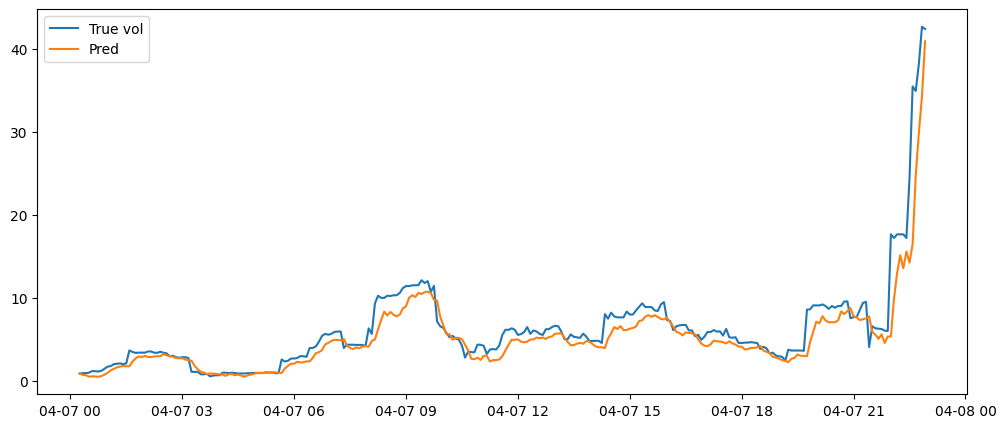

In [105]:
# Plot
if VOL_INTERVAL == "1d":
    x=1
else:
    x=100
plt.figure(figsize=(12,5))
plt.plot(test_scaled_series_list[0][20:].time_index, df_test[0][20:].values()*x, label="True vol")
plt.plot(test_scaled_series_list[0][20:].time_index, pred[0].values()*x, label="Pred")
plt.legend()
plt.show()

#### mediocre MAPE

In [106]:
mean_absolute_percentage_error(pred[0].values()*x, df_test[0][20:].values()*x)

0.2720484783617701

In [107]:
mean_squared_error(pred[0].values()*x, df_test[0][20:].values()*x)

5.078324210890287

# GARCH

In [108]:
df_garch = data_log_returns.copy() * x
# pre traitement pour faire apparaitre tous les indices 
tmp =  TimeSeries.from_dataframe(df_garch.asfreq(DARTS_FREQ), freq=DARTS_FREQ)
df_garch = pd.DataFrame(tmp.values(), index=tmp.time_index).interpolate(method="time")
df_garch[df_garch.isna().any(axis=1)] 

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


,0
Datetime,


In [109]:
df_garch_test = df_garch.loc[df_test[0].time_index[0] :, :]

In [ ]:
# train_end   = int((TRAIN_SIZE + VAL_SIZE) * len(df_garch))


# df_garch_train = df_garch.iloc[:train_end]
# df_garch_test   = df_garch.iloc[train_end:]

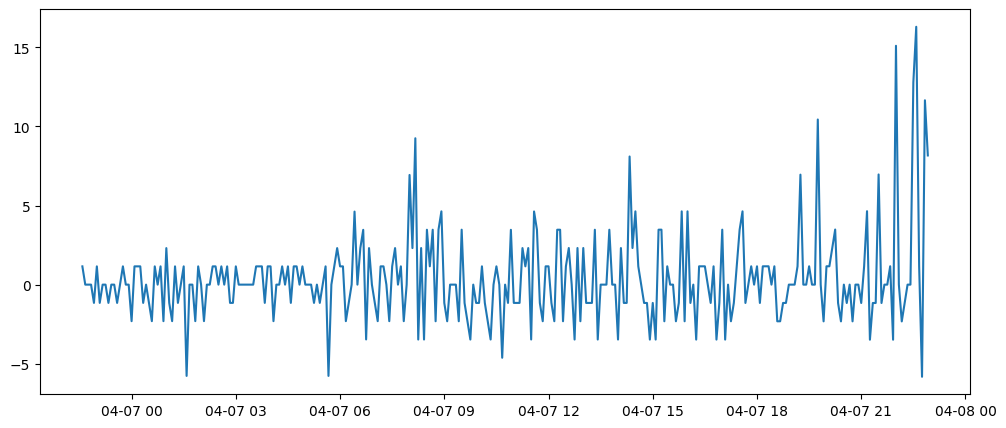

In [110]:
plt.figure(figsize=(12, 5))
plt.plot(df_garch_test.index, df_garch_test.values, label="test")

In [ ]:
# plt.figure(figsize=(12, 5))

# plt.plot(df_garch_train.index, df_garch_train, label="train")
# plt.plot(df_garch_test.index, df_garch_test, label="test")

# plt.title("Data Split")
# plt.legend()
# plt.show()

In [ ]:
# garch_model = arch_model(
#     df_garch_train,
#     vol='GARCH',
#     p=1,
#     q=1
# )
# res = garch_model.fit(disp="off")
# print(res.summary())

In [111]:
history = list(df_garch_test.iloc[0:NBEATS_LOG,0].values)

sigma2_preds = []
sigma2_true = []

for t in range(NBEATS_LOG,len(df_garch_test)):
    
    # Refit avec toutes les vraies données jusqu'à t
    garch_model = arch_model(history[-NBEATS_LOG:], vol='GARCH', p=1, q=1)
    res = garch_model.fit(disp="off")
    
    forecast = res.forecast(horizon=1)
    
    sigma2_t = forecast.variance.values[-1, 0]
    sigma2_preds.append(sigma2_t)
    #sigma2_true.append((df_garch_test.iloc[t,0] - np.mean(history[-5:]))**2)
    #sigma2_true.append((df_garch_test.iloc[t,0])**2)
    
    # Ajouter la vraie observation
    history.append(df_garch_test.iloc[t,0])

In [ ]:
# history = list(df_garch_train.iloc[:,0].values)

# sigma2_preds = []
# sigma2_true = []

# for t in range(len(df_garch_test)):
    
#     # Refit avec toutes les vraies données jusqu'à t
#     garch_model = arch_model(history[-20:], vol='GARCH', p=1, q=1, mean='Constant')
#     res = garch_model.fit(disp="off")
    
#     forecast = res.forecast(horizon=1)
    
#     sigma2_t = forecast.variance.values[-1, 0]
#     sigma2_preds.append(sigma2_t)
#     #sigma2_true.append((df_garch_test.iloc[t,0] - np.mean(history[-5:]))**2)
#     #sigma2_true.append((df_garch_test.iloc[t,0])**2)
    
#     # Ajouter la vraie observation
#     history.append(df_garch_test.iloc[t,0])

In [112]:
sigma2_preds = pd.DataFrame(sigma2_preds).rolling(ROLLING_WINDOW).mean()
sigma2_preds.drop(sigma2_preds.index[:ROLLING_WINDOW], inplace=True) 

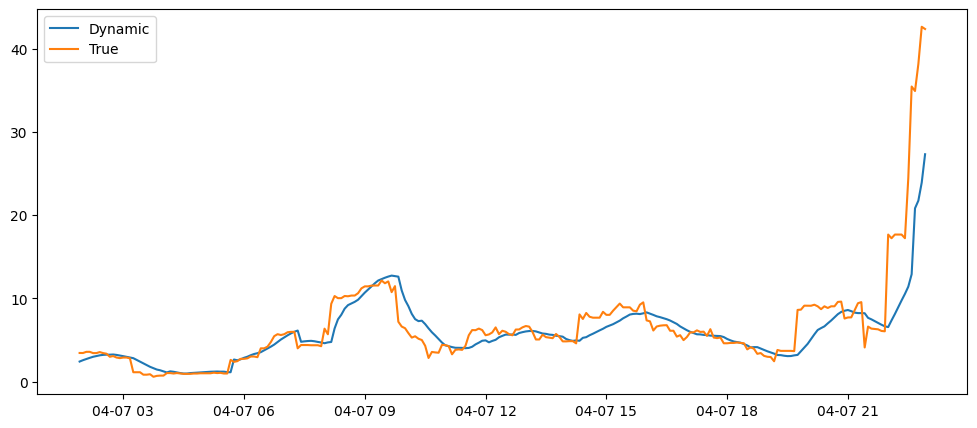

In [113]:

sigma2_true = df.loc[df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:].min():df_garch_test.index.max(),:].iloc[:,0].values * x

plt.figure(figsize=(12,5))
plt.plot(df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:],sigma2_preds* 100/x, label="Dynamic")
plt.plot(df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:],sigma2_true, label="True")
#plt.plot(data_log_returns_sq.loc[df_garch_test.index.min():df_garch_test.index.max(),:], label="True vol")
plt.legend()
plt.show()

In [114]:
mean_absolute_percentage_error(sigma2_preds* 100 / x, sigma2_true)

0.24085647908124988

In [115]:
mean_squared_error(sigma2_preds* 100 / x, sigma2_true)

10.818788739597576

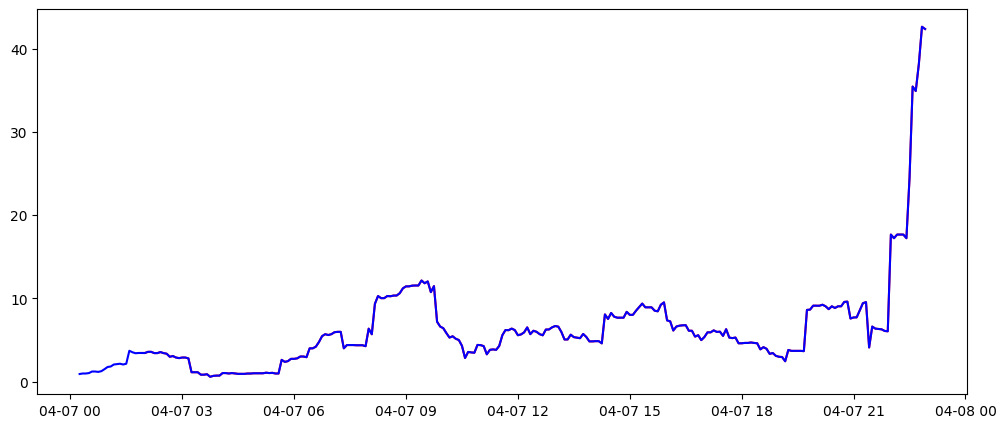

In [116]:
# jsut checking we are testing on the same datas
plt.figure(figsize=(12,5))
plt.plot(df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:],sigma2_true, label="True", c='r')
plt.plot(test_scaled_series_list[0][20:].time_index, df_test[0][20:].values()*x, label="True vol", c='b')

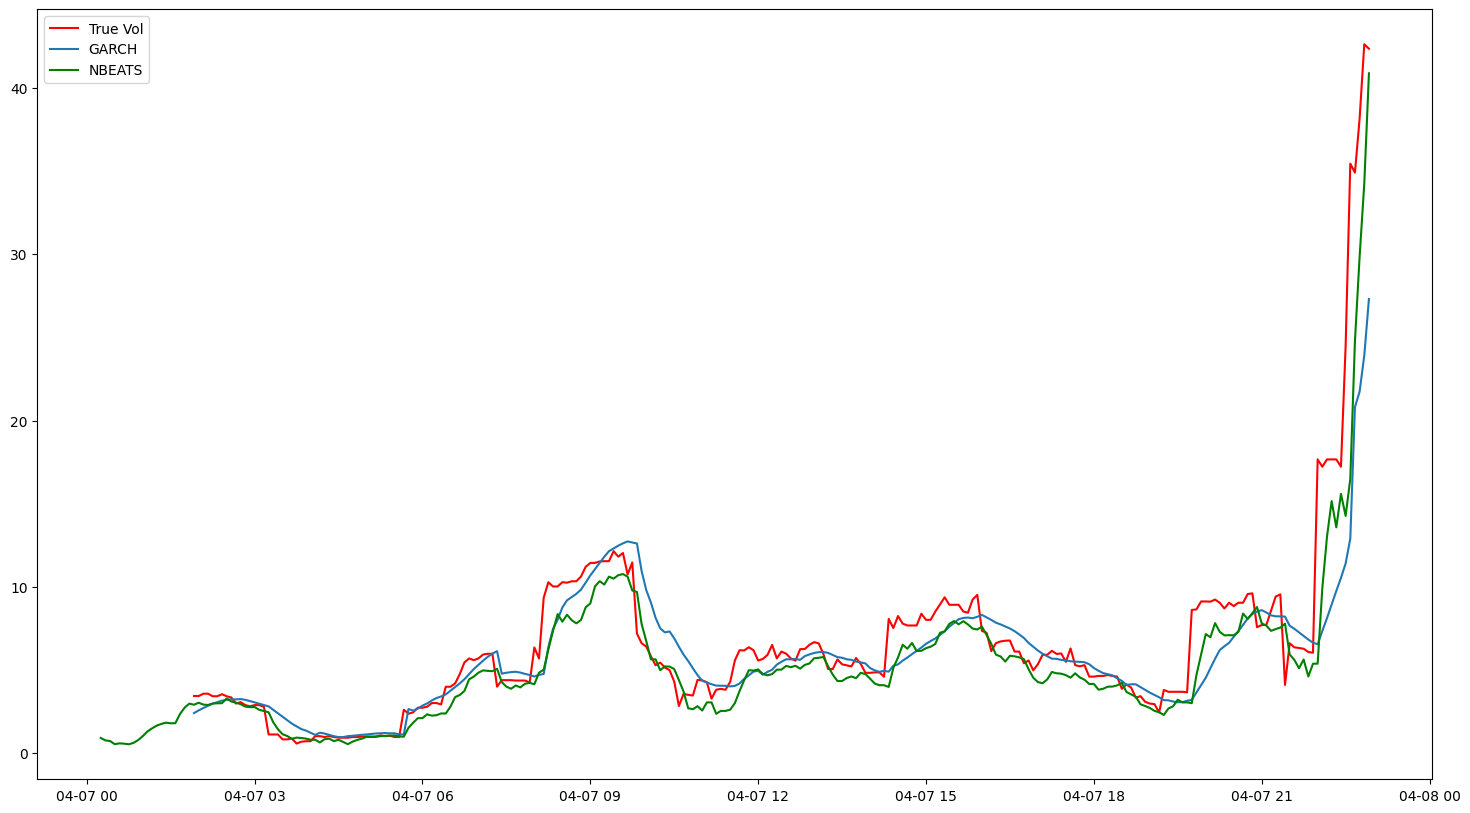

In [118]:

plt.figure(figsize=(18,10))
plt.plot(df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:],sigma2_true, label="True Vol", c='r')
plt.plot(df_garch_test.index[NBEATS_LOG+ROLLING_WINDOW:],sigma2_preds* 100/x, label="GARCH")
plt.plot(test_scaled_series_list[0][20:].time_index, pred[0].values()*x, label="NBEATS", c='g')
plt.legend()